## SafeDerm — 06. Baseline Model

First real model: plain ResNet-50, ImageNet-pretrained, fine-tuned on the training split. This is the baseline `07_champion_model.ipynb`'s CNN+Transformer architecture gets compared against — no transformer head, no calibration, no tricks. Just a solid, honest number to beat.

Model and training/eval loops live in `src/model.py` and `src/engine.py` — `07` reuses these exact functions, so any difference in results reflects the architecture, not a difference in how each was trained or measured.

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader

from src.config import IMAGES_DIR, TRAIN_SPLIT_PATH, VAL_SPLIT_PATH, MODELS_DIR, BASELINE_MODEL_PATH
from src.dataset import SkinLesionDataset, CLASS_TO_IDX
from src.transforms import get_train_transforms, get_eval_transforms
from src.model import build_baseline_model
from src.engine import compute_class_weights, train_one_epoch, evaluate
from src.labels import ALL_CLASSES, MALIGNANT_CLASSES

BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


`NUM_EPOCHS` and `LEARNING_RATE` are a reasonable starting point for full fine-tuning, not tuned yet — adjust based on how the training curves look below.

### Rebuild the pipeline

Same `Dataset`/`DataLoader` setup as `05_pipeline.ipynb` — repeated here so this notebook can run standalone, not because the logic changed.

In [2]:
train_dataset = SkinLesionDataset(TRAIN_SPLIT_PATH, IMAGES_DIR, transform=get_train_transforms())
val_dataset = SkinLesionDataset(VAL_SPLIT_PATH, IMAGES_DIR, transform=get_eval_transforms())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train batches: 219
Val batches  : 48


### Build model, loss, optimizer

Weighted `CrossEntropyLoss` — counters the ~67% `nv` imbalance confirmed in `03_eda.ipynb`. Without this, the model could hit high accuracy by just always predicting `nv`, which would look good on paper and be useless in practice.

In [3]:
model = build_baseline_model().to(device)

class_weights = compute_class_weights(TRAIN_SPLIT_PATH).to(device)
print("Class weights (order matches ALL_CLASSES):")
for cls, w in zip(ALL_CLASSES, class_weights.tolist()):
    print(f"  {cls}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

Class weights (order matches ALL_CLASSES):
  akiec: 4.492
  bcc: 2.763
  bkl: 1.292
  df: 14.046
  mel: 1.290
  nv: 0.213
  vasc: 10.074


### Train

Best model (lowest val loss) gets saved to `models/baseline_resnet50.pt`, not just the last epoch's weights — the last epoch isn't always the best one.

In [4]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_accuracy": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_accuracy, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(f"Epoch {epoch}/{NUM_EPOCHS} — train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_accuracy:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BASELINE_MODEL_PATH)
        print(f"  New best model saved (val_loss: {val_loss:.4f})")

Epoch 1/10 — train_loss: 1.2847  val_loss: 1.0067  val_acc: 0.6201
  New best model saved (val_loss: 1.0067)
Epoch 2/10 — train_loss: 0.7337  val_loss: 0.7609  val_acc: 0.7161
  New best model saved (val_loss: 0.7609)
Epoch 3/10 — train_loss: 0.5977  val_loss: 0.9530  val_acc: 0.6527
Epoch 4/10 — train_loss: 0.4980  val_loss: 0.7313  val_acc: 0.7396
  New best model saved (val_loss: 0.7313)
Epoch 5/10 — train_loss: 0.4107  val_loss: 0.6434  val_acc: 0.7742
  New best model saved (val_loss: 0.6434)
Epoch 6/10 — train_loss: 0.3472  val_loss: 0.8702  val_acc: 0.6984
Epoch 7/10 — train_loss: 0.3296  val_loss: 0.8627  val_acc: 0.6984
Epoch 8/10 — train_loss: 0.3036  val_loss: 0.6775  val_acc: 0.7937
Epoch 9/10 — train_loss: 0.2388  val_loss: 0.7401  val_acc: 0.7441
Epoch 10/10 — train_loss: 0.2238  val_loss: 0.8111  val_acc: 0.7454


### Training curves

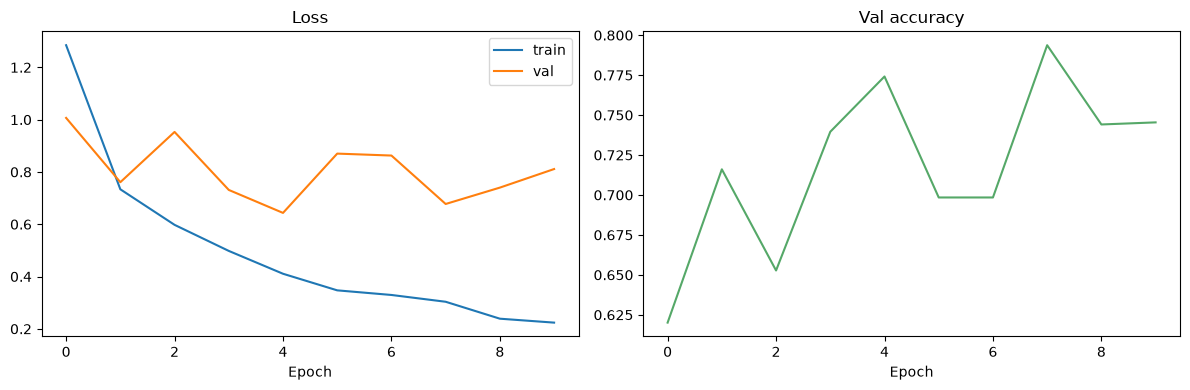

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_accuracy"], color="#55A868")
axes[1].set_title("Val accuracy")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

### Evaluate the best checkpoint

Reload the best-saved weights (not whatever's left in memory from the last epoch) and evaluate properly — confusion matrix and full per-class report.

In [6]:
model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=device))
val_loss, val_accuracy, val_preds, val_labels = evaluate(model, val_loader, criterion, device)

print(f"Best model — val_loss: {val_loss:.4f}  val_accuracy: {val_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(val_labels, val_preds, target_names=ALL_CLASSES))

Best model — val_loss: 0.6434  val_accuracy: 0.7742

Classification report:
              precision    recall  f1-score   support

       akiec       0.45      0.79      0.58        53
         bcc       0.65      0.83      0.73        82
         bkl       0.55      0.64      0.60       160
          df       0.52      0.67      0.58        24
         mel       0.51      0.72      0.60       173
          nv       0.96      0.80      0.87      1018
        vasc       0.78      0.64      0.70        22

    accuracy                           0.77      1532
   macro avg       0.63      0.73      0.66      1532
weighted avg       0.82      0.77      0.79      1532



### Confusion matrix

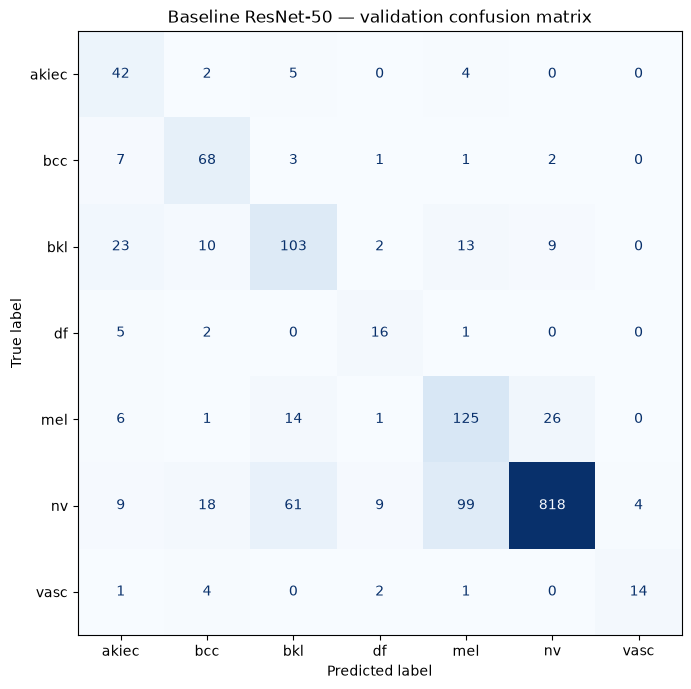

In [7]:
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=ALL_CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Baseline ResNet-50 — validation confusion matrix")
plt.tight_layout()
plt.show()

### Recall on malignant — the metric that actually matters

Overall accuracy is a weak proxy for this project's real goal. What matters: of all the actually-malignant lesions, how many did the model correctly flag? Missing one (a false negative) is the failure mode this project's safety framing exists to prevent — see ADR-004.

In [8]:
malignant_idxs = {CLASS_TO_IDX[cls] for cls in MALIGNANT_CLASSES}

val_labels_binary = [1 if l in malignant_idxs else 0 for l in val_labels]
val_preds_binary = [1 if p in malignant_idxs else 0 for p in val_preds]

tp = sum(1 for t, p in zip(val_labels_binary, val_preds_binary) if t == 1 and p == 1)
fn = sum(1 for t, p in zip(val_labels_binary, val_preds_binary) if t == 1 and p == 0)
malignant_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print(f"Malignant lesions in val set: {tp + fn}")
print(f"Correctly flagged (recall)  : {malignant_recall:.3f}")
print(f"Missed (false negatives)    : {fn}")

Malignant lesions in val set: 308
Correctly flagged (recall)  : 0.831
Missed (false negatives)    : 52


### Summary

- Baseline ResNet-50 trained, best checkpoint saved to `models/baseline_resnet50.pt`.
- Full per-class report and confusion matrix above.
- Malignant recall — the actual safety metric — computed separately from overall accuracy.
- This is the number `07_champion_model.ipynb`'s CNN+Transformer architecture needs to beat, specifically on malignant recall, not just overall accuracy.
- No calibration yet — raw softmax probabilities aren't reliable confidence estimates. That's `08_calibration_conformal.ipynb`'s job.